In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

import numpy as np

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359
maxval=1e9
minval=1e-9

2026-01-09 17:36:03.495961: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767976563.514336 2686943 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767976563.519991 2686943 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767976563.533546 2686943 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767976563.533563 2686943 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767976563.533565 2686943 computation_placer.cc:177] computation placer alr

In [2]:
# # os.chdir('SmartPix/data_generator')
os.chdir('/home/das214/SmartPix/SoftQuantize')
!pwd

/home/das214/SmartPix/SoftQuantize


In [3]:
from DG.OptimizedDataGenerator_v2p5 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.AnnealingScheduler import AnnealingScheduler
from models.models import CreateModel # Conv2D model

In [4]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"
dataset_base_dir = '/depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/'

NOISE_MU = 0.0
NOISE_SIGMA = 80.0 # e-

tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr")

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

os.makedirs(dataset_train_dir, exist_ok=True)
os.makedirs(dataset_test_dir, exist_ok=True)
os.makedirs(tfrecords_dir_train, exist_ok=True)
os.makedirs(tfrecords_dir_val, exist_ok=True)

In [5]:
# batch_size = 5000
# val_batch_size = 5000
# train_file_size = len(os.listdir(dataset_train_dir))
# val_file_size = len(os.listdir(dataset_test_dir))

# start_time = time.time()
# validation_generator = OptimizedDataGenerator(
#     dataset_base_dir = dataset_test_dir,
#     file_type = "parquet",
#     data_format = "3D",
#     batch_size = val_batch_size,
#     # optimize_batch_size = True,
#     file_count = val_file_size,
#     to_standardize= False,
#     select_contained = True,
#     noise = [NOISE_MU,NOISE_SIGMA], #[mean, sigma]
#     min_threshold = None,
#     max_threshold = None,
#     labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
#     input_shape = (2,16,16), # (20,13,21),
#     transpose = (0,2,3,1),
#     shuffle = False, 
#     files_from_end=True,

#     tfrecords_dir = tfrecords_dir_val,
#     use_time_stamps = [0,19],
#     max_workers = 2
# )

# print("--- Validation generator %s seconds ---" % (time.time() - start_time))

# # training generator
# start_time = time.time()
# training_generator = OptimizedDataGenerator(
#     dataset_base_dir = dataset_train_dir,
#     file_type = "parquet",
#     data_format = "3D",
#     batch_size = batch_size,
#     # optimize_batch_size = True,
#     file_count = train_file_size,
#     to_standardize= False,
#     select_contained = True,
#     noise = [NOISE_MU,NOISE_SIGMA], #[mean, sigma]
#     min_threshold = None,
#     max_threshold = None,
#     labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
#     input_shape = (2,16,16), # (20,13,21),
#     transpose = (0,2,3,1),
#     shuffle = False, # True 

#     tfrecords_dir = tfrecords_dir_train,
#     use_time_stamps = [0,19],
#     max_workers = 2
# )
# print("--- Training generator %s seconds ---" % (time.time() - start_time))

In [6]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=True,
    seed=42,
    quantize=False,
)

print("num train batches:", len(training_generator))
print("num val batches  :", len(validation_generator))

b = 0
X, y = training_generator[b]
X = X.numpy()
y = y.numpy()

print("X shape:", X.shape, "dtype:", X.dtype)   # expect (B, H, W, C) or similar
print("y shape:", y.shape, "dtype:", y.dtype)

Loading metadata from /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/metadata.json
Loading metadata from /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/metadata.json


I0000 00:00:1767976574.561930 2686943 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38397 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 7g.40gb, pci bus id: 0000:21:00.0, compute capability: 8.0


num train batches: 84
num val batches  : 21
X shape: (5000, 16, 16, 2) dtype: float32
y shape: (5000, 4) dtype: float32


2026-01-09 17:36:15.079013: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144


X shape: (5000, 16, 16, 2) dtype: <dtype: 'float32'>
y shape: (5000, 4) dtype: <dtype: 'float32'>
Unique values in Q_int: [0 1 2 3]
Q: (5000, 16, 16, 2) int8
Unique values in Q (sample): [0 1 2 3]
tf.Tensor(
[[ 3.37071495e+01 -5.18517075e+01  7.61401443e+01  8.16117172e+01
  -1.23806664e+02 -4.28849936e+00 -3.52379303e+01 -1.62865631e+02
  -5.18621063e+01  5.61058693e+01 -7.78426514e+01 -2.61993618e+01
  -4.08767853e+01  1.32543123e+00 -7.17924881e+01 -1.73919010e+01]
 [ 1.20590057e+02  3.22953072e+01  6.16333427e+01 -7.61424494e+00
   3.59316139e+01  1.03757797e+02  1.18851995e+01 -5.31147156e+01
   2.50447464e+01  8.12093430e+01  1.23492384e+01  9.40042725e+01
  -6.13636436e+01  2.51604137e+01  3.33929710e+01 -6.84607315e+01]
 [-7.35285645e+01  5.06956406e+01  5.12049408e+01  1.13611069e+02
   7.59816217e+00 -9.53501320e+00 -1.59644747e+01 -3.82365913e+01
   9.21189041e+01 -1.17954155e+02 -1.56743179e+02 -2.13926678e+01
  -6.67022943e+00  3.86193037e+00  4.89240036e+01  8.16444473e+0

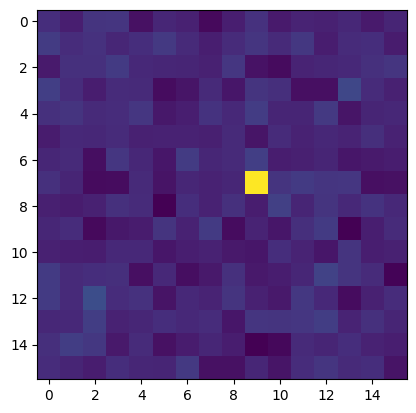

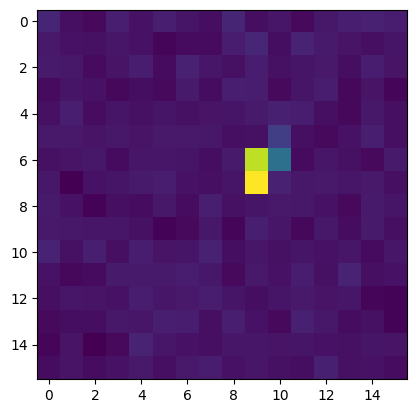

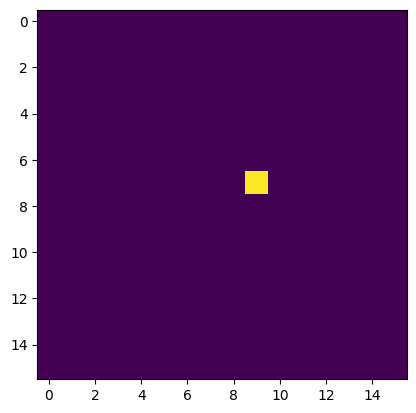

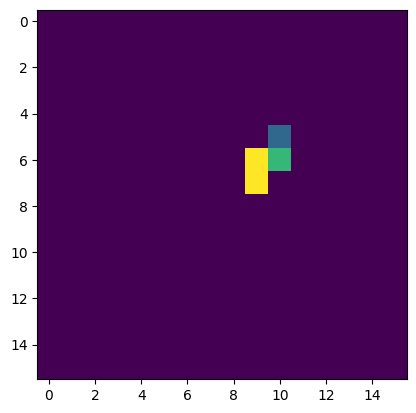

In [7]:
# Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
# Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
# Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16

def create_quantizer_model(input_shape, initial_thresholds, threshold_offset):
    inp = layers.Input(shape=input_shape, name="raw_input")
    q_out = SoftQuantizeLayer(
        n_bits=2,
        initial_levels=np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32),
        threshold_offset=threshold_offset,
        initial_thresholds=initial_thresholds,
        trainable_levels=False,
        trainable_thresholds=False,
        initial_k=50.0,
        trainable_k=True,
        name="soft_quantizer_output"
    )(inp)
    return keras.Model(inputs=inp, outputs=q_out, name="quantizer")

quantizer_model = create_quantizer_model(
    input_shape=(16,16,2),
    initial_thresholds=[249.30, 667.66, 1659.27],
    threshold_offset=80.0
)


b = 0
X, y = training_generator[b]

print("X shape:", X.shape, "dtype:", X.dtype) 
print("y shape:", y.shape, "dtype:", y.dtype)

X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
Q_tf = quantizer_model(X_tf, training=False)     # hard quantize
Q_int = np.rint(Q_tf).astype(np.int8)
u = np.unique(Q_int)
print("Unique values in Q_int:", u)
assert u.min() >= 0 and u.max() <= 3, "Q_int has values outside {0,1,2,3}."
Q = Q_int

print("Q:", Q.shape, Q.dtype)
print("Unique values in Q (sample):", np.unique(Q[: min(200, Q.size)]))

print(X[0, :, :, 0])
print(Q[0, :, :, 0])

plt.imshow(X[0, :, :, 0])
plt.show()

plt.imshow(X[0, :, :, 1])
plt.show()

plt.imshow(Q[0, :, :, 0])
plt.show()

plt.imshow(Q[0, :, :, 1])
plt.show()

# Transformer Model

In [13]:
# Trasformer model

class PatchExtractor(layers.Layer):
  """Extract 2D patches from images."""
  def __init__(self, patch_size=(3,7)):
    super().__init__()
    self.patch_size = patch_size

  def call(self, images):
    # images: (batch, H, W, C)
    patch_h, patch_w = self.patch_size
    batch_size = tf.shape(images)[0]
    patches = tf.image.extract_patches(
        images=images,
        sizes=(1, patch_h, patch_w, 1),
        strides=(1, patch_h, patch_w, 1),
        rates=(1,1,1,1),
        padding='VALID'
    )
    patch_dims = tf.shape(patches)[-1]
    patches = tf.reshape(
        patches,
        [batch_size, -1, patch_dims]
    )
    return patches

class PatchEncoder(layers.Layer):
  """Linear embedding + learnable positional encoding."""
  def __init__(self, num_patches, embed_dim):
    super().__init__()
    self.num_patches = num_patches
    self.projection  = layers.Dense(embed_dim)
    self.pos_embed   = tf.Variable(
        initial_value=tf.zeros((1,num_patches,embed_dim)),
        trainable=True,
        name="pos_embedding"
    )

  def call(self, patch_batch):
    # Linear projection of patch tokens
    projected = self.projection(patch_batch)
    # Add learnable positional embeddings
    return projected + self.pos_embed

def transformer_encoder(inputs,
                        head_size,
                        num_heads,
                        ff_dim,
                        dropout=0.1):
  # LayerNorm + Multi-head attention
  x = layers.LayerNormalization(epsilon=1e-6)(inputs)
  x = layers.MultiHeadAttention(num_heads=num_heads,
                                key_dim=head_size,
                                dropout=dropout)(x, x)
  x = layers.Dropout(dropout)(x)
  res = x + inputs
  
  # Next LN + feed-forward
  x = layers.LayerNormalization(epsilon=1e-6)(res)
  x = layers.Dense(ff_dim, activation="relu")(x)
  x = layers.Dropout(dropout)(x)
  x = layers.Dense(inputs.shape[-1], activation="linear")(x)
  x = layers.Dropout(dropout)(x)
  
  return x + res

def create_vit_model(input_shape=(13,21,2),
                     threshold_offset=80.0,
                     initial_thresholds=[247.8, 668.4, 1662.9],
                     patch_size=(3,7),
                     embed_dim=64,
                     num_heads=4,
                     ff_dim=128,
                     num_layers=4,
                     dropout=0.1,
                     final_outputs=14):
  # Input
  inp = layers.Input(shape=input_shape, name="raw_input")

  q_out = SoftQuantizeLayer(
      n_bits=2,
      initial_levels=np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32),
      threshold_offset=threshold_offset,
      initial_thresholds=initial_thresholds,
      trainable_levels=False,
      trainable_thresholds=False,
      initial_k=1.0,
      trainable_k=True,
      name="soft_quantizer_output"
  )(inp)

  # Extract patches
  patches = PatchExtractor(patch_size=patch_size)(q_out)
  H, W, C = input_shape
  ph, pw  = patch_size
  num_patches = (H // ph) * (W // pw)

  # Encode patches (linear projection + positional embedding)
  encoded_patches = PatchEncoder(num_patches, embed_dim)(patches)

  # Apply multiple Transformer encoder blocks
  x = encoded_patches
  for _ in range(num_layers):
    x = transformer_encoder(x,
                            head_size=embed_dim,
                            num_heads=num_heads,
                            ff_dim=ff_dim,
                            dropout=dropout)
  
  # Flatten and final Dense
  x = layers.LayerNormalization(epsilon=1e-6)(x)
  x = layers.Flatten()(x)
  x = layers.Dense(64, activation='relu')(x)
  outputs = layers.Dense(final_outputs, activation='linear')(x)

  # Create model
  model = keras.Model(inputs=inp, outputs=outputs)
  return model

model = create_vit_model(
    input_shape=(16,16,2),   
    threshold_offset=80.0,
    initial_thresholds=[247.8, 668.4, 1662.9],
    patch_size=(3,4),        
    embed_dim=64,           
    num_heads=4,            
    ff_dim=128,              
    num_layers=4,            
    dropout=0.1,             
    final_outputs=14         
)

model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_input           │ (None, 16, 16, 2) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soft_quantizer_out… │ (None, 16, 16, 2) │          4 │ raw_input[0][0]   │
│ (SoftQuantizeLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor_2   │ (None, None, 24)  │          0 │ soft_quantizer_o… │
│ (PatchExtractor)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder_2     │ (None, 20, 64)    │      1,600 │ patch_extractor_… │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ patch_encoder_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 20, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 20, 64)    │          0 │ dropout_33[0][0], │
│                     │                   │            │ patch_encoder_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_16[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 20, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 20, 128)   │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 20, 64)    │      8,256 │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 20, 64)    │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 20, 64)    │          0 │ dropout_35[0][0], │
│                     │                   │            │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_17[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 20, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 417,426 (1.59 MB)

 Trainable params: 417,423 (1.59 MB)

 Non-trainable params: 3 (12.00 B)

In [14]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_LUT_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, "weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5")

# 9f5e5c2c : 1000 epochs
print(checkpoint_filepath)
print(fingerprint)

./trained_LUT_models/model-293e61d7-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5
293e61d7


In [15]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [16]:
history = model.fit(
        x=training_generator,
        validation_data=validation_generator,
        callbacks=[mcp, csv_logger, es],
        epochs=50,
        shuffle=False,
        verbose=1
    )

Epoch 1/50


2026-01-09 15:46:51.671972: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27', 336 bytes spill stores, 336 bytes spill loads

2026-01-09 15:46:51.761904: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27', 72 bytes spill stores, 72 bytes spill loads

2026-01-09 15:46:51.771296: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25', 336 bytes spill stores, 336 bytes spill loads

2026-01-09 15:46:51.883342: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25', 72 bytes spill stores, 72 bytes spill loads

2026-01-09 15:46:51.894565: I external/local

 5/84 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 103616.3281

2026-01-09 15:47:12.483209: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_29', 12 bytes spill stores, 12 bytes spill loads

2026-01-09 15:47:12.641145: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27', 72 bytes spill stores, 72 bytes spill loads

2026-01-09 15:47:12.714883: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25', 336 bytes spill stores, 336 bytes spill loads

2026-01-09 15:47:12.723533: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27', 336 bytes spill stores, 336 bytes spill loads

2026-01-09 15:47:12.731693: I external/local

12/84 ━━━━━━━━━━━━━━━━━━━━ 2:16 2s/step - loss: 103528.1172

...

82/84 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - loss: 103533.0234

2026-01-09 15:49:00.938542: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27', 72 bytes spill stores, 72 bytes spill loads

2026-01-09 15:49:01.037060: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_29', 12 bytes spill stores, 12 bytes spill loads

2026-01-09 15:49:01.185049: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_25', 336 bytes spill stores, 336 bytes spill loads

2026-01-09 15:49:01.185075: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_27', 72 bytes spill stores, 72 bytes spill loads

2026-01-09 15:49:01.200814: I external/local_x

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 103519.4766

2026-01-09 15:49:17.667874: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 140 bytes spill stores, 140 bytes spill loads

2026-01-09 15:49:17.711179: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 112 bytes spill stores, 112 bytes spill loads

2026-01-09 15:49:17.743996: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 68 bytes spill stores, 68 bytes spill loads

2026-01-09 15:49:17.795223: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 248 bytes spill stores, 252 bytes spill loads

2026-01-09 15:49:17.796566: I external/local_x

84/84 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 103512.6328 - val_loss: 102746.0000
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 103512.9375 - val_loss: 102746.0000
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/ste

# Patch Analysis

In [8]:
from collections import Counter

def extract_patches(Q, patch_dim, stride=None, padding=None):
    """
    Q: (B,H,W,C) with discrete values (e.g. {0,1,2,3})
    patch_dim: (pH,pW)
    stride: (dY,dX) or None -> non-overlapping
    padding:
      - None: no padding (VALID)
      - "same": auto-pad so you cover the full image with the given stride
    """
    B, H, W, C = Q.shape
    pH, pW = patch_dim

    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride


    pad_top = pad_bot = pad_left = pad_right = 0

    if padding is None:
        pass
    elif padding == "same":
        # number of patch positions (like conv output size)
        nY = int(np.ceil(H / dY)) if dY > 0 else 1
        nX = int(np.ceil(W / dX)) if dX > 0 else 1

        H_pad = (nY - 1) * dY + pH
        W_pad = (nX - 1) * dX + pW

        padY = max(0, H_pad - H)
        padX = max(0, W_pad - W)

        pad_top  = padY // 2
        pad_bot  = padY - pad_top
        pad_left = padX // 2
        pad_right= padX - pad_left


    if any(v != 0 for v in (pad_top, pad_bot, pad_left, pad_right)):
        pad_width = ((0, 0), (pad_top, pad_bot), (pad_left, pad_right), (0, 0))
        Q = np.pad(Q, pad_width, mode="constant", constant_values=0)

    # update dims after padding
    B, H, W, C = Q.shape

    patches_ctr = Counter()
    for b in range(B):
        for c in range(C):
            for y in range(0, H - pH + 1, dY):
                for x in range(0, W - pW + 1, dX):
                    patch = Q[b, y:y+pH, x:x+pW, c]
                    key = tuple(patch.reshape(-1).tolist())
                    patches_ctr[key] += 1

    return patches_ctr


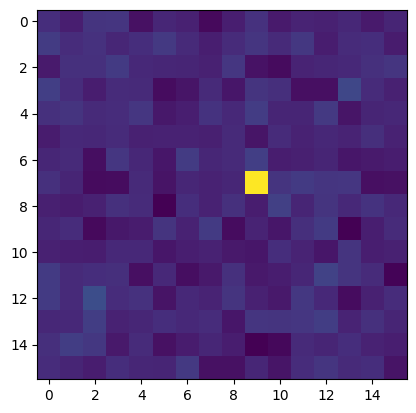

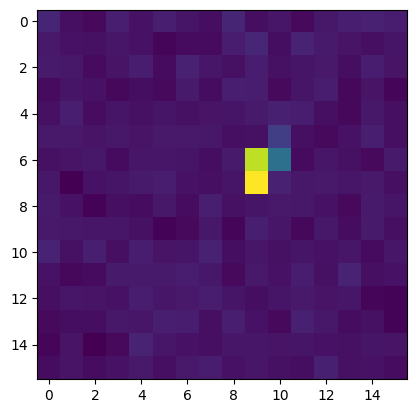

In [9]:
plt.imshow(X[0, :, :, 0])
plt.show()

plt.imshow(X[0, :, :, 1])
plt.show()

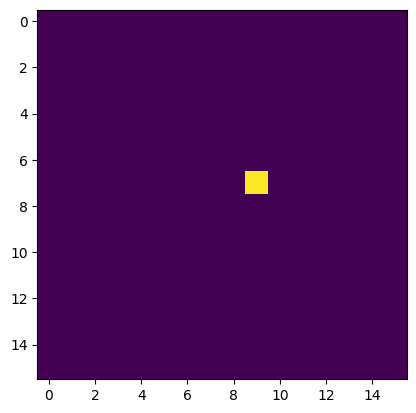

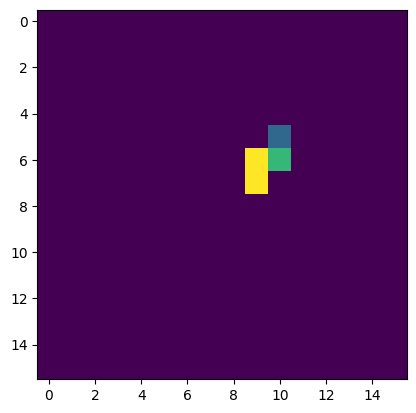

In [10]:
plt.imshow(Q[0, :, :, 0])
plt.show()

plt.imshow(Q[0, :, :, 1])
plt.show()

In [11]:
patch_dim = (1, 1)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)

#patches: 2560000
#unique patches: 4


In [12]:
patch_dim = (4, 4)
patches_ctr = extract_patches(Q, patch_dim)

npatch = sum(patches_ctr.values())
nuniq  = len(patches_ctr)

print("#patches:", npatch)
print("#unique patches:", nuniq)
print("first 5 patches:")

levels = set()
print("Top 10 patches:")
for pat, cnt in patches_ctr.most_common(10):
    print(pat, cnt)
    levels |= set(pat)
print("levels seen in patches:", levels)


#patches: 160000
#unique patches: 10106
first 5 patches:
Top 10 patches:
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 124933
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1) 712
(1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 708
(0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 702
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0) 683
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3) 499
(3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 476
(0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 474
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0) 460
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0) 442
levels seen in patches: {0, 1, 2, 3}


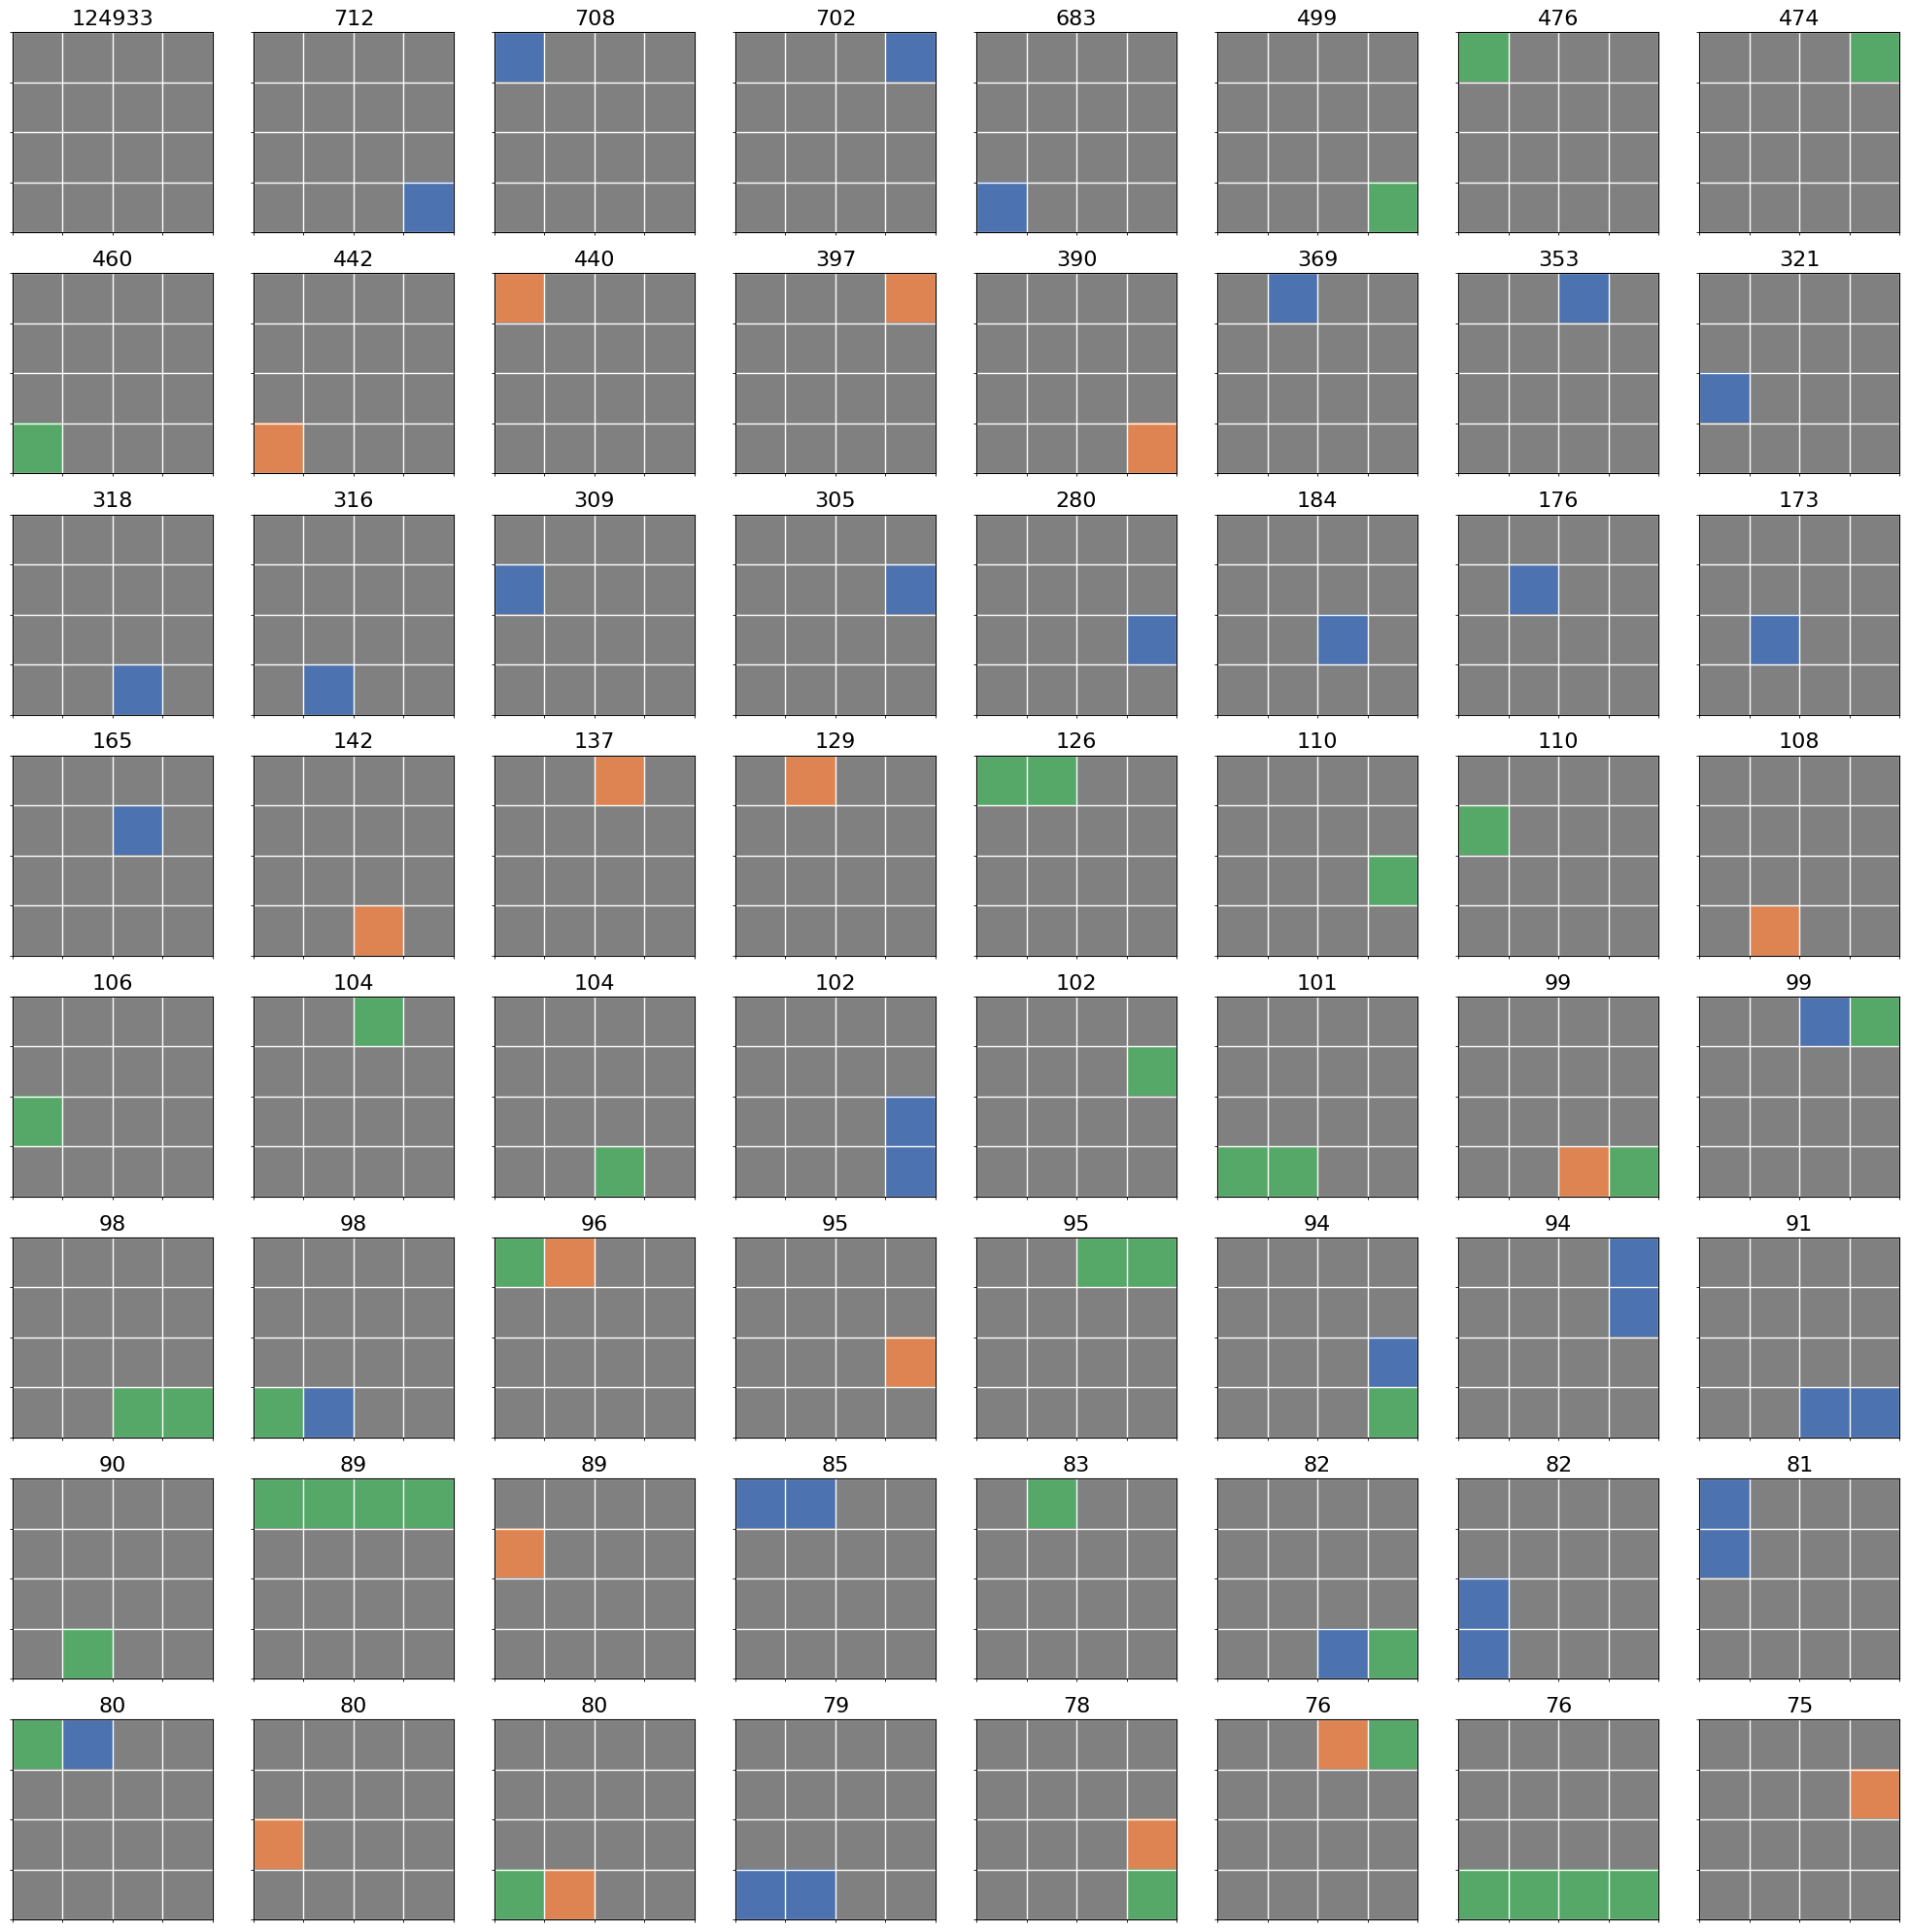

In [13]:
K = 64

from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(8, 8, figsize=(20,20))
cmap = ListedColormap(["grey", "#4C72B0", "#DD8452", "#55A868"])

for ax, (pat, cnt) in zip(axes.flat, patches_ctr.most_common(K)):
    img = np.array(pat).reshape(patch_dim)

    ax.imshow(img, cmap=cmap, vmin=0, vmax=3)

    # ---- draw pixel grid ----
    h, w = img.shape
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)

    # ---- clean axes ----
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(cnt, fontsize=16)

plt.tight_layout()
plt.show()


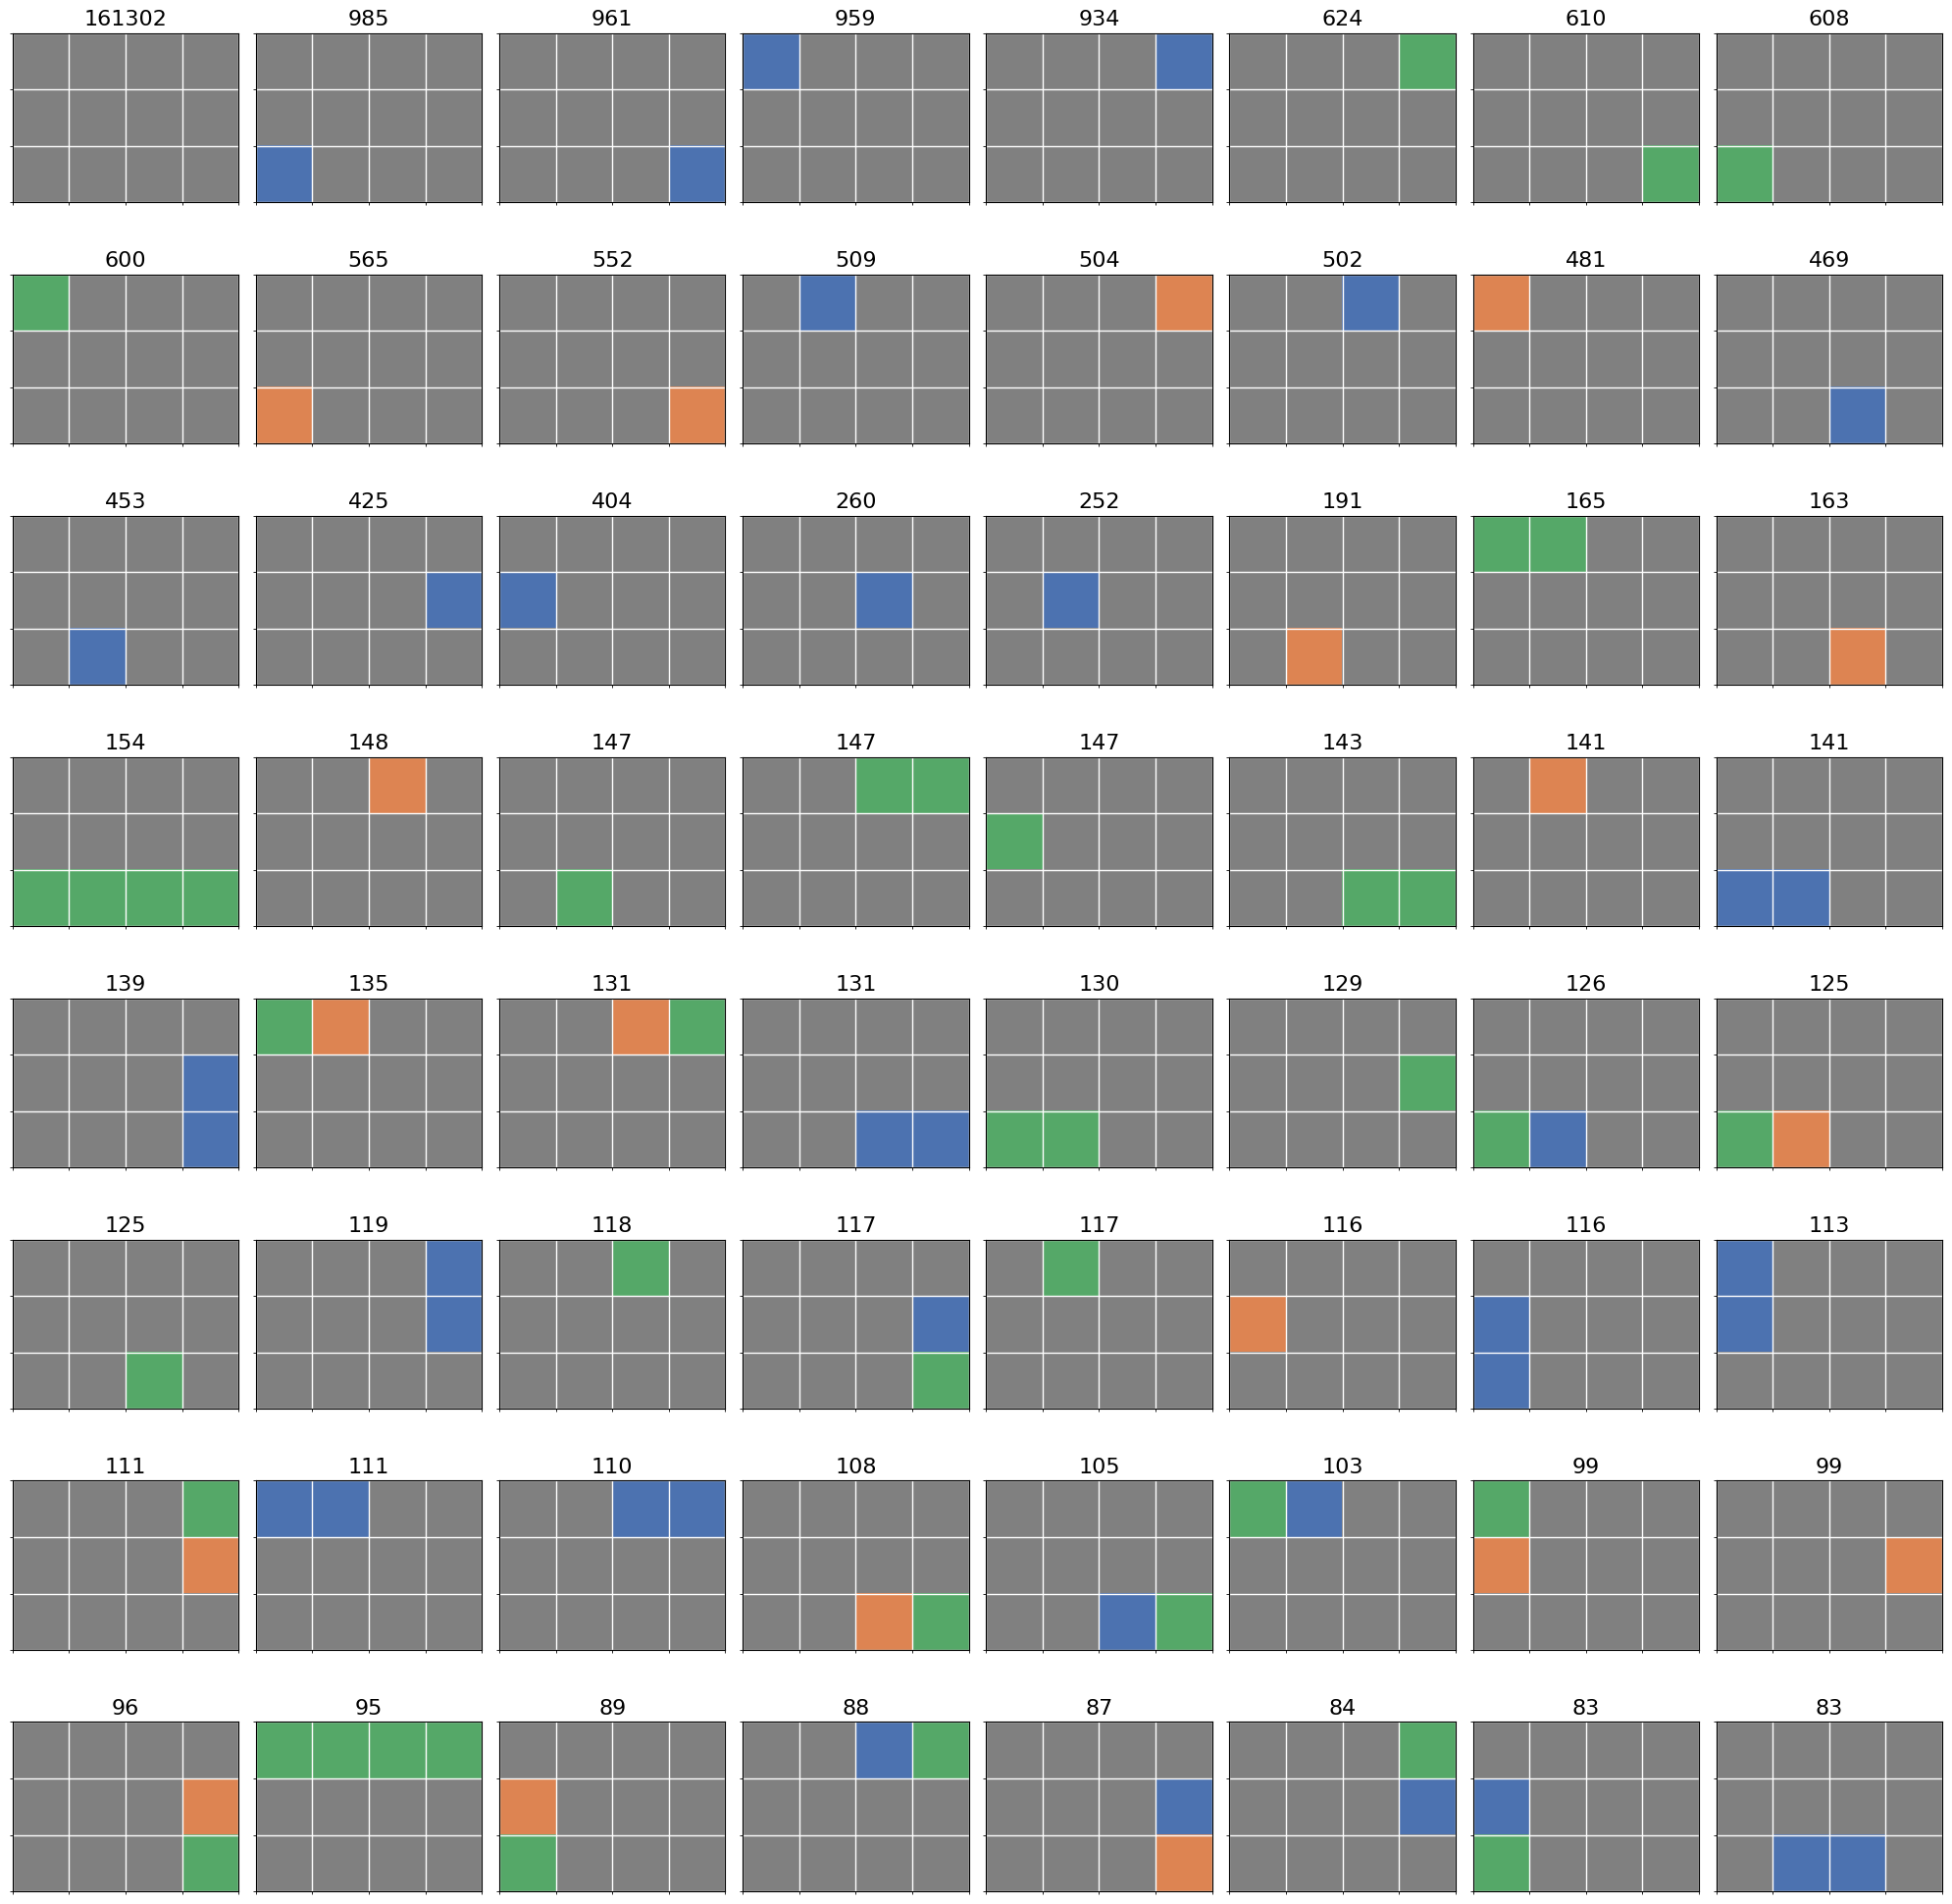

In [14]:
K = 64

patch_dim = (3, 4)
patches_ctr = extract_patches(Q, patch_dim)

fig, axes = plt.subplots(8, 8, figsize=(20,20))
cmap = ListedColormap(["grey", "#4C72B0", "#DD8452", "#55A868"])

for ax, (pat, cnt) in zip(axes.flat, patches_ctr.most_common(K)):
    img = np.array(pat).reshape(patch_dim)

    ax.imshow(img, cmap=cmap, vmin=0, vmax=3)

    # ---- draw pixel grid ----
    h, w = img.shape
    ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0)

    # ---- clean axes ----
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(cnt, fontsize=16)

plt.tight_layout()
plt.show()

In [15]:
def estimate_bits_per_cell_from_topK(patches_ctr, pH, pW, K):
    """
    Simple top-K dictionary + ESC model:
      - encode symbol among (top-K patches + ESC) with ideal entropy H_sym (lower bound)
      - if ESC, transmit raw patch payload (pH*pW*bits_per_entry)

    Returns: (bits_per_cell, p_esc, H_sym_bits_per_patch)
    """
    total = sum(patches_ctr.values())  # total patch *occurrences*
    top = patches_ctr.most_common(K)
    top_counts = np.array([cnt for _, cnt in top], dtype=np.float64)

    levels = set()
    for pat, cnt in top:
        levels |= set(pat)
    n_levels = max(1, len(levels))
    bits_per_entry= np.ceil(np.log2(n_levels))
    
    p_top = top_counts / total
    p_esc = max(0.0, 1.0 - float(p_top.sum()))  # clamp for numerical safety

    # symbol distribution over K+1 symbols (K dictionary entries + ESC)
    p_sym = np.concatenate([p_top, np.array([p_esc])])
    p_nonzero = p_sym[p_sym > 0] # avoid log(0)
    H_sym = -np.sum(p_nonzero * np.log2(p_nonzero))  # bits per patch for symbol (ideal)

    raw_payload_bits = (pH * pW * bits_per_entry)  # sent only on ESC
    bits_per_patch = H_sym + p_esc * raw_payload_bits
    bits_per_cell = bits_per_patch / (pH * pW)

    return bits_per_cell, p_esc, H_sym

In [16]:
patch_dims = [(1,1), (2,2), (3,3), (4,4), (8,8)]
Ks = [8, 16, 32, 64, 128, 256, 512]

rows = []

print(f"{'patch':>9} {'K':>6} {'Keff':>6} {'bits/cell':>10} {'p_esc':>10} {'Hsym(b/patch)':>14} {'#patches':>10} {'#unique':>10}")

for (pH, pW) in patch_dims:
    patches_ctr = extract_patches(Q_int, (pH, pW), stride=None)  # non-overlapping
    npatch = sum(patches_ctr.values())
    nuniq  = len(patches_ctr)

    for K in Ks:
        K_eff = min(K, nuniq) if nuniq > 0 else 0

        bits_cell, p_esc, Hsym = estimate_bits_per_cell_from_topK(
            patches_ctr, pH, pW, K_eff
        )

        print(f"{str((pH,pW)):>9} {K:6d} {K_eff:6d} {bits_cell:10.4f} {p_esc:10.4f} {Hsym:14.4f} {npatch:10d} {nuniq:10d}")

        rows.append((pH, pW, K_eff, bits_cell, p_esc, Hsym, npatch, nuniq))


    patch      K   Keff  bits/cell      p_esc  Hsym(b/patch)   #patches    #unique
   (1, 1)      8      4     0.3016     0.0000         0.3016    2560000          4
   (1, 1)     16      4     0.3016     0.0000         0.3016    2560000          4
   (1, 1)     32      4     0.3016     0.0000         0.3016    2560000          4
   (1, 1)     64      4     0.3016     0.0000         0.3016    2560000          4
   (1, 1)    128      4     0.3016     0.0000         0.3016    2560000          4
   (1, 1)    256      4     0.3016     0.0000         0.3016    2560000          4
   (1, 1)    512      4     0.3016     0.0000         0.3016    2560000          4
   (2, 2)      8      8     0.2713     0.0603         0.6031     640000        255
   (2, 2)     16     16     0.2599     0.0402         0.7178     640000        255
   (2, 2)     32     32     0.2558     0.0270         0.8072     640000        255
   (2, 2)     64     64     0.2523     0.0135         0.9013     640000        255
   (

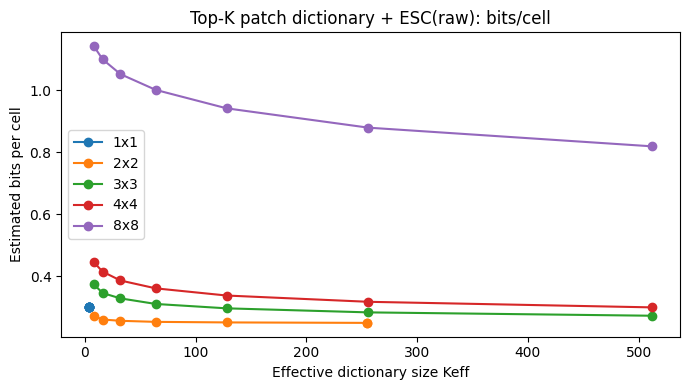

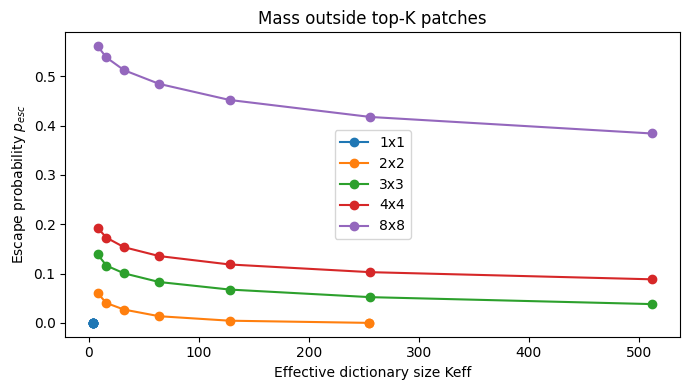

In [17]:
import pandas as pd

df = pd.DataFrame(rows, columns=["pH","pW","Keff","bits_cell","p_esc","Hsym","npatch","nuniq"])
df["patch"] = df["pH"].astype(str) + "x" + df["pW"].astype(str)

# bits/cell vs K (use original Ks on x-axis, but you stored Keff; easiest is plot vs Keff)
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["bits_cell"], marker="o", label=patch)
# plt.xscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Estimated bits per cell")
plt.title("Top-K patch dictionary + ESC(raw): bits/cell")
plt.legend()
plt.tight_layout()
plt.show()

# p_esc vs Keff
plt.figure(figsize=(7,4))
for patch, g in df.groupby("patch"):
    g2 = g.sort_values("Keff")
    plt.plot(g2["Keff"], g2["p_esc"], marker="o", label=patch)
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Effective dictionary size Keff")
plt.ylabel("Escape probability $p_{esc}$")
plt.title("Mass outside top-K patches")
plt.legend()
plt.tight_layout()
plt.show()

# Patch ID

In [18]:
from tqdm import tqdm
def extract_gbl_patch_ctr(data_gen, quantizer_model, patch_dim, stride=None, padding=None, max_batches=None):
    """
    Returns global Counter over ALL patches in the dataset (as seen through the generator).
    """
    global_ctr = Counter()
    n_seen = 0
    for (X, _) in tqdm(data_gen, desc="Building Global Patch-CTR"):
        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        Q_tf = quantizer_model(X_tf, training=False)
        Q_int = np.rint(Q_tf.numpy()).astype(np.uint8)

        batch_ctr = extract_patches(Q_int, patch_dim, stride=stride, padding=padding)
        global_ctr += batch_ctr

        n_seen += 1
        if max_batches is not None and n_seen >= int(max_batches):
            break

    return global_ctr

In [19]:
def build_patch_dict_from_counter(patches_ctr, K, unk_id=0):
    """
    patch2id maps top-K patches to IDs 1..K. 0 reserved for UNK.
    """
    patch2id = {}
    K_eff = min(int(K), len(patches_ctr))  # guard if K > #unique
    for i, (pat, _) in enumerate(patches_ctr.most_common(K_eff), start=1):
        patch2id[pat] = i
    return patch2id, unk_id

In [20]:
def build_patch_LUT(patch2id, patch_dim, *, unk_id=0):
    """
    Returns tf.lookup.StaticHashTable mapping base-4 encoded patch key -> token id.

    base-4 key: key = sum_{j=0..K-1} patch[j] * 4^j   (K = pH*pW)
    """
    pH, pW = patch_dim
    K = pH * pW
    pow4 = (4 ** np.arange(K, dtype=np.int64))

    keys_np = np.array(
        [np.dot(np.asarray(pat, dtype=np.int64), pow4) for pat in patch2id.keys()],
        dtype=np.int64
    )
    vals_np = np.array(list(patch2id.values()), dtype=np.int64)

    init = tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(keys_np, dtype=tf.int64),
        values=tf.constant(vals_np, dtype=tf.int64),
        key_dtype=tf.int64,
        value_dtype=tf.int64,
    )
    table = tf.lookup.StaticHashTable(init, default_value=tf.constant(unk_id, tf.int64))
    return table, keys_np, vals_np

In [21]:
def tokenize_batch(Q_int, patch_dim, patch_LUT,
                   stride=None, padding=None, *,
                   unk_id=0, return_coords=False,
                   # CHANGE: add NN-fallback inputs + metric/threshold
                   # REASON: allow replacing unk_id with closest dictionary patch id
                   dict_keys=None, dict_ids=None,
                   nn_metric="l1", max_dist=None):
    """
    dict_keys: (M,) int64 base-4 encoded patch keys for ALL dictionary entries
    dict_ids : (M,) int32 token ids aligned with dict_keys
    nn_metric: "l1" or "hamming"
    max_dist: optional int; if nearest distance > max_dist, keep unk_id
    """

    pH, pW = patch_dim
    if stride is None:
        dY, dX = pH, pW
    else:
        dY, dX = stride

    Q = tf.convert_to_tensor(Q_int)
    B = tf.shape(Q)[0]
    H = tf.shape(Q)[1]
    W = tf.shape(Q)[2]
    C = tf.shape(Q)[3]

    # (B,H,W,C) -> (B,C,H,W,1) -> (B*C,H,W,1)
    Q_bc = tf.transpose(Q, [0, 3, 1, 2])
    Q_bc = tf.reshape(Q_bc, [-1, H, W, 1])

    padding_tf = "VALID" if padding is None else str(padding).upper()

    patches = tf.image.extract_patches(
        images=Q_bc,
        sizes=[1, pH, pW, 1],
        strides=[1, dY, dX, 1],
        rates=[1, 1, 1, 1],
        padding=padding_tf,
    )  # (B*C, out_h, out_w, K)

    K = pH * pW
    powv = tf.pow(tf.constant(4, tf.int64), tf.range(K, dtype=tf.int64))  # (K,)
    keys = tf.reduce_sum(tf.cast(patches, tf.int64) * powv, axis=-1)      # (B*C, out_h, out_w)

    ids = patch_LUT.lookup(keys)  # int64
    out_h = tf.shape(ids)[1]
    out_w = tf.shape(ids)[2]

    # CHANGE: nearest-neighbor fallback for unknown keys
    # REASON: replace unk_id by closest dictionary entry in patch space
    if dict_keys is not None and dict_ids is not None:
        unk_id_i64 = tf.cast(unk_id, ids.dtype)
        unk_mask = tf.equal(ids, unk_id_i64)

        if tf.reduce_any(unk_mask):
            # flatten (B*C*out_h*out_w)
            patches_flat = tf.reshape(patches, [-1, K])          # dtype like Q (uint8/int)
            ids_flat     = tf.reshape(ids, [-1])
            unk_mask_f   = tf.reshape(unk_mask, [-1])

            unk_patches = tf.boolean_mask(patches_flat, unk_mask_f)  # (N,K)
            unk_patches = tf.cast(unk_patches, tf.int16)

            dk = tf.convert_to_tensor(dict_keys, tf.int64)
            di = tf.convert_to_tensor(dict_ids, tf.int32)

            # drop any entry that maps to unk_id (just in case)
            keep = tf.not_equal(di, tf.cast(unk_id, tf.int32))
            dk = tf.boolean_mask(dk, keep)
            di = tf.boolean_mask(di, keep)

            # decode base-4 key -> patch digits (M,K)
            dict_patches = tf.math.floordiv(dk[:, None], powv[None, :]) % 4
            dict_patches = tf.cast(dict_patches, tf.int16)

            # distances (N,M)
            if str(nn_metric).lower() == "hamming":
                dist = tf.reduce_sum(
                    tf.cast(tf.not_equal(unk_patches[:, None, :], dict_patches[None, :, :]), tf.int32),
                    axis=-1
                )
            else:  # "l1"
                dist = tf.reduce_sum(tf.abs(unk_patches[:, None, :] - dict_patches[None, :, :]), axis=-1)

            nn_idx = tf.argmin(dist, axis=1, output_type=tf.int32)     # (N,)
            nn_ids = tf.gather(di, nn_idx)                             # (N,)
            min_d  = tf.reduce_min(dist, axis=1)                       # (N,)

            if max_dist is not None:
                max_dist_i = tf.cast(max_dist, min_d.dtype)
                nn_ids = tf.where(min_d <= max_dist_i, nn_ids, tf.cast(unk_id, tf.int32))

            pos = tf.where(unk_mask_f)[:, 0]                           # (N,)
            ids_flat = tf.tensor_scatter_nd_update(
                ids_flat,
                tf.expand_dims(pos, 1),
                tf.cast(nn_ids, ids_flat.dtype)
            )
            ids = tf.reshape(ids_flat, tf.shape(ids))

    ids = tf.reshape(ids, [B, C, out_h, out_w])        # (B,C,oy,ox)
    tokens = tf.reshape(ids, [B, C * out_h * out_w])   # (B,L)
    tokens = tf.cast(tokens, tf.int32)

    if not return_coords:
        return tokens

    if padding_tf == "VALID":
        y0 = tf.range(out_h, dtype=tf.int32) * dY
        x0 = tf.range(out_w, dtype=tf.int32) * dX
    else:
        out_h_same = (H + dY - 1) // dY
        out_w_same = (W + dX - 1) // dX

        padY = tf.maximum((out_h_same - 1) * dY + pH - H, 0)
        padX = tf.maximum((out_w_same - 1) * dX + pW - W, 0)
        pad_top  = padY // 2
        pad_left = padX // 2

        y0 = tf.range(out_h, dtype=tf.int32) * dY - pad_top
        x0 = tf.range(out_w, dtype=tf.int32) * dX - pad_left

    yy, xx = tf.meshgrid(y0, x0, indexing="ij")  # (oy,ox)
    yx = tf.stack([tf.reshape(yy, [-1]), tf.reshape(xx, [-1])], axis=1)  # (oy*ox,2)

    Lsp = tf.shape(yx)[0]
    ccol = tf.repeat(tf.range(C), Lsp)
    yx_rep = tf.tile(yx, [C, 1])
    coords = tf.concat([tf.expand_dims(ccol, 1), yx_rep], axis=1)  # (L,3) = (c,y,x)

    return tokens, coords


In [22]:
def decode_tokens_to_patches(tokens,
                             patch_dim,
                             *,
                             dict_keys,   # (M,) int64 base-4 keys
                             dict_ids,    # (M,) int32/int64 token ids aligned with dict_keys
                            ):
    """
    Decode token IDs back to patch digits.

    Args
    ----
    tokens:    (B,L) int32/int64
    patch_dim: (pH,pW)
    dict_keys: (M,) int64 base-4 keys for dictionary entries
    dict_ids:  (M,) token ids corresponding to dict_keys

    Returns
    -------
    patches: (B,L,pH,pW) int16
    """

    pH, pW = patch_dim
    K = pH * pW

    tokens = tf.convert_to_tensor(tokens)
    tokens_i64 = tf.cast(tokens, tf.int64)

    dk = tf.convert_to_tensor(np.asarray(dict_keys, dtype=np.int64), tf.int64)
    di = tf.convert_to_tensor(np.asarray(dict_ids,  dtype=np.int64), tf.int64)

    # Build id -> key LUT (default key=0; we'll override UNK separately)
    init = tf.lookup.KeyValueTensorInitializer(
        keys=tf.cast(di, tf.int64),
        values=tf.cast(dk, tf.int64),
        key_dtype=tf.int64,
        value_dtype=tf.int64,
    )
    id2key = tf.lookup.StaticHashTable(init, default_value=tf.constant(0, tf.int64))

    keys = id2key.lookup(tokens_i64)  # (B,L) int64

    # Decode base-4 digits in the same convention as your encoder:
    # key = sum_j digit[j] * 4^j  => digit[j] = floor(key / 4^j) % 4
    powv = tf.pow(tf.constant(4, tf.int64), tf.range(K, dtype=tf.int64))  # (K,)
    digits = (keys[..., None] // powv[None, None, :]) % 4                # (B,L,K)
    digits = tf.cast(digits, tf.int16)

    patches = tf.reshape(digits, [tf.shape(tokens_i64)[0], tf.shape(tokens_i64)[1], pH, pW])
    return patches


In [23]:
class TokenizedSequence(keras.utils.Sequence):
    def __init__(self, base_seq, quantizer_model, patch_dim, patch_LUT,
                 dict_keys_np, dict_ids_np, tfrecords_dir=None,
                 unk_id=0, stride=None, padding=None,
                 patches_out_type=tf.int16, y_out_type=tf.float32,
                 compression=None,  # None | "GZIP" | "ZLIB"
                 write_on_init=True):
        self.base = base_seq
        self.qm = quantizer_model
        self.patch_dim = patch_dim
        self.patch_LUT = patch_LUT
        self.unk_id = unk_id
        self.stride = stride
        self.padding = padding

        if tfrecords_dir is None:
            tfrecords_dir = os.path.join(self.base.tfrecords_dir, "patches")
        self.tfrecords_dir = tfrecords_dir

        self.dict_keys = np.asarray(dict_keys_np, dtype=np.int64)
        self.dict_ids  = np.asarray(dict_ids_np,  dtype=np.int32)

        self.patches_out_type = patches_out_type
        self.y_out_type = y_out_type
        self.compression = compression

        if write_on_init:
            self.write_tfrecords(self.tfrecords_dir, compression=self.compression)

        self.tfrecord_files = np.sort(np.array(
            tf.io.gfile.glob(os.path.join(self.tfrecords_dir, "*.tfrecord"))
        ))

    def __len__(self):
        return len(self.base)

    def _tokenize(self, Q_int):
        tokens = tokenize_batch(
            Q_int,
            self.patch_dim,
            self.patch_LUT,
            stride=self.stride,
            padding=self.padding,
            unk_id=self.unk_id,
            dict_keys=self.dict_keys,
            dict_ids=self.dict_ids.astype(np.int32),
            nn_metric="l1",
            max_dist=None
        )
        return tokens

    def _decode_tokens_to_patches(self, tokens):
        patches = decode_tokens_to_patches(
            tokens,
            patch_dim=self.patch_dim,
            dict_keys=self.dict_keys,
            dict_ids=self.dict_ids,
        )
        return patches



    
    def __getitem__(self, idx):
        if self.tfrecord_files is None or len(self.tfrecord_files) == 0:
            raise ValueError(f"No TFRecord files found in: {self.tfrecords_dir}")

        path = self.tfrecord_files[idx]
        ds = tf.data.TFRecordDataset(path, compression_type=(self.compression or ""))
        ds = ds.map(self._parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)

        # take the single record
        it = iter(ds)
        try:
            patches, y = next(it)
        except StopIteration:
            raise ValueError(f"Empty TFRecord file: {path}")

        return patches, y




    
    @staticmethod
    def _bytes_feature(value):
        if isinstance(value, type(tf.constant(0))):
            value = value.numpy()
        return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

    def _serialize_example(self, patches, y, patches_dtype=tf.int16, y_dtype=tf.float32):
        patches = tf.cast(patches, patches_dtype)
        y = tf.cast(y, y_dtype)

        feat = {
            "patches": self._bytes_feature(tf.io.serialize_tensor(patches)),
            "y":       self._bytes_feature(tf.io.serialize_tensor(y)),
        }
        ex = tf.train.Example(features=tf.train.Features(feature=feat))
        return ex.SerializeToString()

    def get_patches(self, X, y):
        X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
        Q_tf = self.qm(X_tf, training=False)
        Q_int = tf.cast(tf.round(Q_tf), tf.int64)

        tokens = self._tokenize(Q_int)                     # (B,L)
        patches = self._decode_tokens_to_patches(tokens)   # (B,L,pH,pW) (or similar)

        B, L, pH, pW = patches.shape
        patches_flat = tf.reshape(patches, [B, L, pH * pW]) # (B,L,pH * pW)
    
        return patches_flat

    def write_tfrecords(
        self,
        tfrecords_dir: str,
        *,
        max_batches: int = None,
        prefix: str = "batch",
        compression: str = None,     # None | "GZIP" | "ZLIB"
        patches_dtype=tf.int16,
        y_dtype=tf.float32,
        verbose: int = 1,
    ):
        os.makedirs(tfrecords_dir, exist_ok=True)

        n_total = len(self.base)
        n_write = n_total if max_batches is None else min(int(max_batches), n_total)

        options = None
        if compression is not None:
            options = tf.io.TFRecordOptions(compression_type=compression)

        it = range(n_write)
        if verbose:
            print(f"[TokenizedSequence] Writing {n_write}/{n_total} batches -> {tfrecords_dir}")
            it = tqdm(it, desc="[TokenizedSequence] Writing TFRecords", unit="batch")
        
        for i in it:
            X, y = self.base[i]  # X: (B,H,W,C) float32, y: (B,...) numpy
            patches = self.get_patches(X, y)   # (B,L,pH,pW) (or similar)

            patches_tf = tf.convert_to_tensor(patches)
            y_tf = tf.convert_to_tensor(y)

            out_path = os.path.join(tfrecords_dir, f"{prefix}_{i:06d}.tfrecord")
            rec = self._serialize_example(patches_tf, y_tf, patches_dtype, y_dtype)

            with tf.io.TFRecordWriter(out_path, options=options) as w:
                w.write(rec)

        if verbose:
            print("[TokenizedSequence] Done.")

    def _parse_tfrecord_fn(self, example):
        feature_description = {
            "patches": tf.io.FixedLenFeature([], tf.string),
            "y":       tf.io.FixedLenFeature([], tf.string),
        }
        ex = tf.io.parse_single_example(example, feature_description)

        patches = tf.io.parse_tensor(ex["patches"], out_type=self.patches_out_type)
        y       = tf.io.parse_tensor(ex["y"],       out_type=self.y_out_type)

        return patches, y

# Patching

In [92]:
patch_dim = (2, 2)
unk_id=0
patches_ctr = extract_gbl_patch_ctr(
    training_generator, 
    quantizer_model,
    patch_dim=patch_dim,
    stride=None,
    padding="same",
    max_batches=None      # set e.g. 1 for a quick approximation
)

K = 256
patch2id, unk_id = build_patch_dict_from_counter(patches_ctr, K, unk_id)
vocab_size = K + 1
print(patch2id)
print(unk_id)
print(vocab_size)

Building Global Patch-CTR: 100%|██████████| 84/84 [01:31<00:00,  1.09s/it]

{(0, 0, 0, 0): 1, (0, 1, 0, 0): 2, (1, 0, 0, 0): 3, (0, 0, 1, 0): 4, (0, 0, 0, 1): 5, (0, 3, 0, 0): 6, (3, 0, 0, 0): 7, (0, 0, 0, 3): 8, (0, 0, 3, 0): 9, (0, 0, 2, 0): 10, (0, 0, 0, 2): 11, (3, 3, 0, 0): 12, (2, 0, 0, 0): 13, (0, 2, 0, 0): 14, (0, 0, 3, 3): 15, (0, 1, 0, 1): 16, (1, 0, 1, 0): 17, (0, 2, 0, 2): 18, (2, 0, 2, 0): 19, (0, 0, 1, 1): 20, (1, 1, 0, 0): 21, (0, 3, 0, 3): 22, (3, 0, 3, 0): 23, (0, 2, 0, 3): 24, (2, 0, 3, 0): 25, (3, 0, 2, 0): 26, (0, 3, 0, 2): 27, (0, 0, 2, 3): 28, (3, 2, 0, 0): 29, (2, 3, 0, 0): 30, (0, 0, 3, 2): 31, (0, 0, 1, 3): 32, (0, 0, 3, 1): 33, (3, 1, 0, 0): 34, (1, 3, 0, 0): 35, (2, 3, 3, 0): 36, (3, 2, 0, 3): 37, (2, 0, 1, 0): 38, (0, 2, 0, 1): 39, (3, 0, 2, 3): 40, (0, 3, 3, 2): 41, (0, 1, 0, 2): 42, (1, 0, 2, 0): 43, (1, 1, 1, 1): 44, (3, 0, 1, 0): 45, (0, 3, 0, 1): 46, (1, 0, 3, 0): 47, (0, 1, 0, 3): 48, (3, 3, 0, 3): 49, (3, 0, 3, 3): 50, (0, 3, 3, 3): 51, (3, 3, 3, 0): 52, (1, 1, 0, 1): 53, (1, 1, 1, 0): 54, (2, 0, 3, 3): 55, (3, 3, 2, 0): 56, 

In [93]:
patch_LUT, dict_keys_np, dict_ids_np = build_patch_LUT(patch2id, patch_dim, unk_id=unk_id)
dict_ids_np = dict_ids_np.astype(np.int32)

In [94]:
# usage
train_tok = TokenizedSequence(
    training_generator, quantizer_model, patch_dim, patch_LUT,
    dict_keys_np, dict_ids_np,
    unk_id=unk_id, stride=None, padding="same",
    patches_out_type=tf.int16, y_out_type=tf.float32,
    compression=None,          # or "GZIP"
    write_on_init=True
)

val_tok = TokenizedSequence(
    validation_generator, quantizer_model, patch_dim, patch_LUT,
    dict_keys_np, dict_ids_np,
    unk_id=unk_id, stride=None, padding="same",
    patches_out_type=tf.int16, y_out_type=tf.float32,
    compression=None,
    write_on_init=True
)

t0, y0 = train_tok[0]
print("patches:", t0.shape, t0.dtype, "y:", y0.shape, y0.dtype)

seq_len = t0.shape[1]
print("seq_len:", seq_len)

[TokenizedSequence] Writing 84/84 batches -> /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_train/patches


[TokenizedSequence] Writing TFRecords: 100%|██████████| 84/84 [00:11<00:00,  7.10batch/s]


[TokenizedSequence] Done.
[TokenizedSequence] Writing 21/21 batches -> /depot/cms/users/das214/datasets/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/TFR_files/2t_N_0.0mu_80.0sig_NoLog_Stdr/TFR_val/patches


[TokenizedSequence] Writing TFRecords: 100%|██████████| 21/21 [00:02<00:00,  8.23batch/s]

[TokenizedSequence] Done.
patches: (5000, 128, 4) <dtype: 'int16'> y: (5000, 4) <dtype: 'float32'>
seq_len: 128


X shape: (5000, 16, 16, 2) dtype: <dtype: 'float32'>
y shape: (5000, 4) dtype: <dtype: 'float32'>
Unique values in Q_int: [0 1 2 3]
Q: (5000, 16, 16, 2) int8
Unique values in Q (sample): [0 1 2 3]


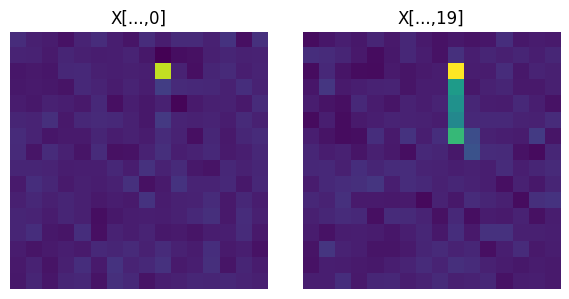

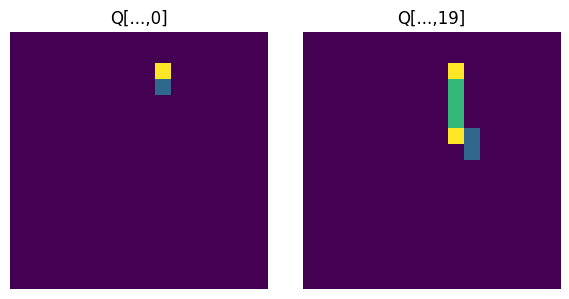

In [95]:
# Th0: μ=249.30 ± 1.06, σ=4.50 ± 0.75
# Th1: μ=667.66 ± 2.08, σ=8.84 ± 1.47
# Th2: μ=1659.27 ± 5.88, σ=24.97 ± 4.16

from matplotlib.colors import Normalize


b = 0
i = 10
X, y = training_generator[b]

print("X shape:", X.shape, "dtype:", X.dtype) 
print("y shape:", y.shape, "dtype:", y.dtype)

X_tf = tf.convert_to_tensor(X, dtype=tf.float32)
Q_tf = quantizer_model(X_tf, training=False)     # hard quantize
Q_int = np.rint(Q_tf).astype(np.int8)
u = np.unique(Q_int)
print("Unique values in Q_int:", u)
assert u.min() >= 0 and u.max() <= 3, "Q_int has values outside {0,1,2,3}."
Q = Q_int

print("Q:", Q.shape, Q.dtype)
print("Unique values in Q (sample):", np.unique(Q[: min(200, Q.size)]))

# print(X[0, :, :, 0])
# print(Q[0, :, :, 0])

Xnp = X.numpy() if hasattr(X, "numpy") else np.asarray(X)

img0 = Xnp[i, :, :, 0]
img1 = Xnp[i, :, :, 1]

# shared scale (use fixed [0,3] if these are quantized levels)
vmin = min(img0.min(), img1.min())
vmax = max(img0.max(), img1.max())
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

im0 = axes[0].imshow(img0, norm=norm, interpolation="nearest")
axes[0].set_title("X[...,0]")
axes[0].axis("off")

im1 = axes[1].imshow(img1, norm=norm, interpolation="nearest")
axes[1].set_title("X[...,19]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

img0 = Q[i, :, :, 0]
img1 = Q[i, :, :, 1]

# shared scale (use fixed [0,3] if these are quantized levels)
vmin = min(img0.min(), img1.min())
vmax = max(img0.max(), img1.max())
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

im0 = axes[0].imshow(img0, norm=norm, interpolation="nearest")
axes[0].set_title("Q[...,0]")
axes[0].axis("off")

im1 = axes[1].imshow(img1, norm=norm, interpolation="nearest")
axes[1].set_title("Q[...,19]")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [96]:
Q.shape

(5000, 16, 16, 2)

seq shape = (128, 2, 2), showing n=128 patches, shared vmin=0, vmax=3


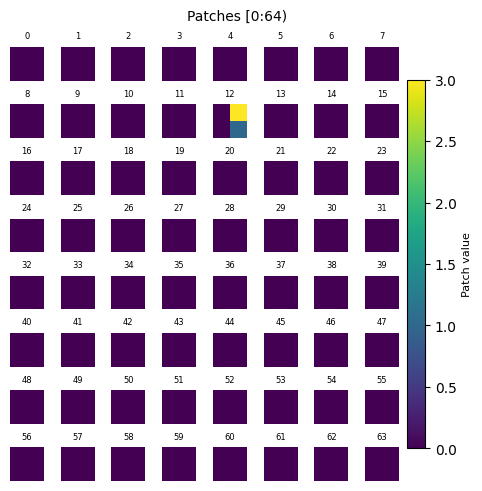

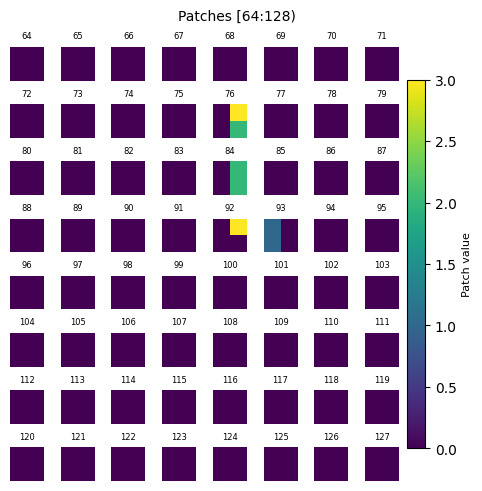

In [97]:
pH, pW = patch_dim
ncols = Q.shape[2] // pW
n_show = 512             # how many patches to show total (max)

# patches_np must exist (from your earlier cell)
patches, _ = train_tok[0]
patches_np = patches.numpy() if hasattr(patches, "numpy") else np.asarray(patches)

seq = np.asarray(patches_np[i]).reshape(-1, pH, pW)   # (n_patches,2,2)
n = min(n_show, seq.shape[0])
half = n // 2

# ---- GLOBAL scale over ALL patches you will show (both pages) ----
vmin = float(seq[:n].min())
vmax = float(seq[:n].max())
norm = Normalize(vmin=vmin, vmax=vmax)

print(f"seq shape = {seq.shape}, showing n={n} patches, shared vmin={vmin:.3g}, vmax={vmax:.3g}")

# ---------------- Page 1: [0:half) ----------------
m = half
nrows = int(np.ceil(m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 0.6, nrows * 0.6), constrained_layout=True)
axes = np.asarray(axes).ravel()

im = None
for k, t in enumerate(range(0, half)):
    im = axes[k].imshow(seq[t], interpolation="nearest", norm=norm, cmap="viridis")
    axes[k].set_title(str(t), fontsize=6)
    axes[k].axis("off")
for k in range(m, axes.size):
    axes[k].axis("off")

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Patch value", fontsize=8)
fig.suptitle(f"Patches [0:{half})", fontsize=10)
plt.show()

# ---------------- Page 2: [half:n) ----------------
m = n - half
nrows = int(np.ceil(m / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 0.6, nrows * 0.6), constrained_layout=True)
axes = np.asarray(axes).ravel()

im = None
for k, t in enumerate(range(half, n)):
    im = axes[k].imshow(seq[t], interpolation="nearest", norm=norm, cmap="viridis")
    axes[k].set_title(str(t), fontsize=6)
    axes[k].axis("off")
for k in range(m, axes.size):
    axes[k].axis("off")

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Patch value", fontsize=8)
fig.suptitle(f"Patches [{half}:{n})", fontsize=10)
plt.show()


# LUT Model

In [98]:
dictionary_list = [list(pat) for pat in patch2id.keys()]
dictionary_np = np.array(dictionary_list, dtype=np.float32)

print("Dictionary shape:", dictionary_np.shape)

Dictionary shape: (256, 4)


In [99]:
# # CHANGE: Use keras.ops (Keras 3) instead of raw tf.* ops on KerasTensors.
# # REASON: KerasTensor cannot be passed to TensorFlow functions during Functional graph construction.

# import tensorflow as tf
# import keras
# from keras import layers


#     self.num_patches = num_patches
#     self.projection  = layers.Dense(embed_dim)
#     self.pos_embed   = tf.Variable(
#         initial_value=tf.zeros((1,num_patches,embed_dim)),
#         trainable=True,
#         name="pos_embedding"
#     )

# def create_basis_model(
#         seq_len, patch_dim, dictionary_np,
#         d_model=32, n_heads=4, ff=64, n_layers=3,
#         n_outputs=14,
#     ):
#     pH, pW = patch_dim
#     vocab_size, patch_size = dictionary_np.shape  # (K, patch_size)

#     # 1) Input: (B, L, patch_size)
#     patches_in = layers.Input(shape=(seq_len, patch_size), name="patch_input")

#     # 2) Fixed dictionary: (K, patch_size)
#     # Keep it as a constant; we will use it via keras.ops inside a Lambda.
#     basis_lut = tf.constant(dictionary_np, dtype=tf.float32)

#     # 3) Soft assignment: similarity = patches @ basis^T  -> (B, L, K)
#     def soft_assign(x):
#         sim = keras.ops.matmul(x, keras.ops.transpose(basis_lut))  # (B,L,K)
#         w = keras.ops.softmax(sim, axis=-1)
#         return w

#     attention_weights = layers.Lambda(soft_assign, name="soft_assign")(patches_in)

#     # 4) Project to d_model
#     x = layers.Dense(d_model, name="proj_to_dmodel")(attention_weights)

#     # 5) Positional embedding (avoid tf.range)
#     pos_emb_layer = layers.Embedding(input_dim=seq_len, output_dim=d_model, name="pos_emb")

#     def add_pos(z):
#         pos = keras.ops.arange(seq_len)                  # (L,)
#         pos = keras.ops.expand_dims(pos, axis=0)         # (1,L)
#         return z + pos_emb_layer(pos)                    # broadcast to (B,L,d)

#     x = layers.Lambda(add_pos, name="add_pos")(x)

#     # 6) Transformer blocks
#     for i in range(n_layers):
#         # Self-attention
#         x0 = x
#         x = layers.LayerNormalization(epsilon=1e-5, name=f"ln_attn_{i}")(x)
#         x = layers.MultiHeadAttention(
#             num_heads=n_heads,
#             key_dim=d_model // n_heads,
#             name=f"mha_{i}"
#         )(x, x)
#         x = layers.Add(name=f"res_attn_{i}")([x0, x])

#         # FFN
#         x0 = x
#         x = layers.LayerNormalization(epsilon=1e-5, name=f"ln_ffn_{i}")(x)
#         x = layers.Dense(ff, activation="gelu", name=f"ff1_{i}")(x)
#         x = layers.Dense(d_model, name=f"ff2_{i}")(x)
#         x = layers.Add(name=f"res_ffn_{i}")([x0, x])

#     x = layers.LayerNormalization(epsilon=1e-5, name="ln_out")(x)
#     x = layers.GlobalAveragePooling1D(name="avg_pool")(x)

#     # Head (as you had it)
#     x = layers.Dense(64, activation="relu", name="head_fc1")(x)
#     x = layers.Dense(64, activation="relu", name="head_fc2")(x)
#     x = layers.Dense(64, activation="relu", name="head_fc3")(x)
#     x = layers.Dense(64, activation="relu", name="head_fc4")(x)
#     out = layers.Dense(n_outputs, name="head")(x)

#     return keras.Model(patches_in, out, name="basis_softassign_transformer")


# # usage (unchanged)
# lut_model = create_basis_model(
#     seq_len=seq_len, patch_dim=patch_dim, dictionary_np=dictionary_np,
#     d_model=16, n_heads=4, ff=32, n_layers=3,
#     n_outputs=14
# )

# lut_model.compile(
#     optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
#     loss=custom_loss,
# )

# lut_model.summary()

In [100]:
def create_patch_LUT_model(
    seq_len, patch_dim,
    d_model=64, n_heads=4, ff=128, n_layers=3,
    n_outputs=14, dropout=0.1
    ):
    
    pH, pW = patch_dim

    # INPUT LAYER
    # patches_in = layers.Input(shape=(seq_len, pH, pW), dtype=tf.float32, name="patch_patterns") #(B, Seq_Len, pH, pW)
    patches_in = layers.Input(shape=(seq_len, pH * pW), dtype=tf.float32, name="patch_patterns") #(B, Seq_Len, pH * pW)
    patches_emb = layers.Reshape((seq_len, pH * pW))(patches_in) # (B, L, pH, pW) -> (B, L, pH * pW)
    patches_emb = layers.Dense(d_model, name="pattern_projection")(patches_emb)
    
    pos_emb = tf.Variable(
        initial_value=tf.zeros((1,seq_len,d_model)),
        trainable=True,
        name="pos_embedding"
    )
    x = patches_emb + pos_emb

    for i in range(n_layers):
        # Self-attn block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model//n_heads)(x, x)
        x = tf.keras.layers.Add()([x0, x])

        # FFN block
        x0 = x
        x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
        x = tf.keras.layers.Dense(ff, activation="gelu")(x)
        x = tf.keras.layers.Dense(d_model)(x)
        x = tf.keras.layers.Add()([x0, x])

    x = tf.keras.layers.LayerNormalization(epsilon=1e-5)(x)
    x = layers.Flatten()(x)

    # Head
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)

    out = tf.keras.layers.Dense(n_outputs, name="head")(x)

    return tf.keras.Model(patches_in, out)

lut_model = create_patch_LUT_model(
    seq_len=seq_len,
    patch_dim=patch_dim,
    d_model=32,    # smaller
    n_heads=4,
    ff=64,
    n_layers=3,
    n_outputs=14,
)
lut_model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

lut_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patch_patterns      │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 128, 4)    │          0 │ patch_patterns[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pattern_projection  │ (None, 128, 32)   │        160 │ reshape_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 128, 32)   │          0 │ pattern_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_28[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 32)   │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 128, 32)   │          0 │ add_28[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_29[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 128, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 128, 32)   │      2,080 │ dense_40[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 128, 32)   │          0 │ add_29[0][0],     │
│                     │                   │            │ dense_41[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_30[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 32)   │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 128, 32)   │          0 │ add_30[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_31[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 128, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 128, 32)   │      2,080 │ dense_42[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_32 (Add)        │ (None, 128, 32)   │          0 │ add_31[0][0],     │
│                     │                   │            │ dense_43[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 32)   │         64 │ add_32[0][0]    

 Total params: 301,454 (1.15 MB)

 Trainable params: 301,454 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [101]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_LUT_models/model-{fingerprint}-checkpoints'

checkpoints_dir = os.path.join(base_dir, 'checkpoints')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(checkpoints_dir, exist_ok=True) 
checkpoint_filepath = os.path.join(checkpoints_dir, "weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5")

In [102]:
# 9f5e5c2c : 1000 epochs
print(checkpoint_filepath)
print(fingerprint)

./trained_LUT_models/model-0572a5c8-checkpoints/checkpoints/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.weights.h5
0572a5c8


In [103]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback
import csv

early_stopping_patience = 50
es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=True,
       save_freq='epoch'
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [ ]:
history = lut_model.fit(
    train_tok,
    validation_data=val_tok,
    callbacks=[mcp, csv_logger, es],
    epochs=1000,
    verbose=1
)

Epoch 1/1000
13/84 ━━━━━━━━━━━━━━━━━━━━ 2:30 2s/step - loss: 53385.3984

In [ ]:
def plot_keras_history(history):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h['loss'], 'o-', label='Train Loss', markersize=3)
    plt.plot(epochs, h['val_loss'], 'o-', label='Val Loss', markersize=3)
    plt.title('Loss vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Log-Loss Plot (Crucial for your 100k loss values)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h['loss'], 'o-', label='Train Loss', markersize=3)
    plt.plot(epochs, h['val_loss'], 'o-', label='Val Loss', markersize=3)
    plt.yscale('log')
    plt.title('Loss vs. Epochs (Log Scale)')
    plt.xlabel('Epochs')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

# Call the function
plot_keras_history(history)